# Infectious Disease Spread

In [12]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
%matplotlib inline

## SIR Model definitions

In [13]:
def sir_model(y, t, beta, gamma):
    S, I, R = y
    N = S + I + R

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

## Initialize

In [14]:
# Total population
N = 100000

# Initial infected and recovered
I0 = 10
R0_init = 0
S0 = N - I0 - R0_init

# Disease parameters
beta = 0.3      # transmission rate
gamma = 0.1     # recovery rate

# Basic reproduction number
R0 = beta / gamma
print(f"Basic Reproduction Number R0 = {R0:.2f}")

# Time grid (days)
t = np.linspace(0, 160, 160)

Basic Reproduction Number R0 = 3.00


## RUn

In [15]:
# Initial conditions vector
y0 = [S0, I0, R0_init]

# Solve ODE
solution = odeint(sir_model, y0, t, args=(beta, gamma))
S, I, R = solution.T

## Plot

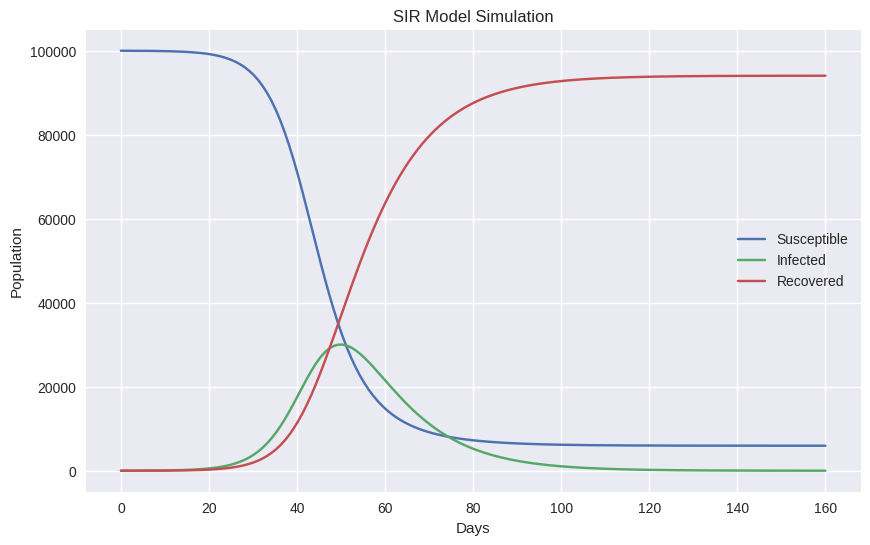

In [16]:
plt.figure(figsize=(10,6))

plt.plot(t, S, label="Susceptible")
plt.plot(t, I, label="Infected")
plt.plot(t, R, label="Recovered")

plt.xlabel("Days")
plt.ylabel("Population")
plt.title("SIR Model Simulation")
plt.legend()
plt.show()